IBM HR Analytics Employee Attrition & Performance
NAME: ZAIN ALI
ROLL NO: 24F-BSAI-010
SECTION:A1

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [31]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")



In [32]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [33]:
print(df.shape)
print(df.info)
print(df.columns)



(1470, 35)
<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Educatio

In [34]:
print(df.dtypes)

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [35]:

print(df.isnull().sum())
print(df.isnull().sum().sum()) #here i got value 0 which means i have no missing valuse

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [36]:
df = df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [37]:
from sklearn.preprocessing import LabelEncoder

lebel = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = lebel.fit_transform(df[column])

#here i used "for" loop bec they were many columns with str datatype so here we created a loop which converts everycolumn where it find the dataype "object" 

In [38]:
print(df.head())
print(df.dtypes)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0  Female  ...               

In [39]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1176, 30)
(294, 30)


In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'Travel_Rarely'

In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()

model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)

NameError: name 'X_train_scaled' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

print("Logistic Regression")
print("Acc:", accuracy_score(y_test, y_pred1))
print("F1 score:", f1_score(y_test, y_pred1))

Logistic Regression


NameError: name 'y_pred1' is not defined

In [ ]:
cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

NameError: name 'y_pred1' is not defined

In [ ]:
model2 = DecisionTreeClassifier(random_state=42)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

NameError: name 'X_train' is not defined

In [ ]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("F1 Score:", f1_score(y_test, y_pred2))

Decision Tree


NameError: name 'y_pred2' is not defined

In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

NameError: name 'y_pred2' is not defined

In [ ]:
model3 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

NameError: name 'X_train' is not defined

In [ ]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("F1 Score:", f1_score(y_test, y_pred3))

Random Forest


NameError: name 'y_pred3' is not defined

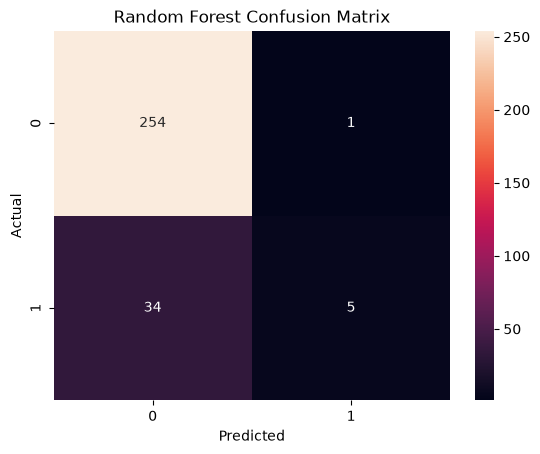

In [ ]:
cm3 = confusion_matrix(y_test, y_pred3)

sns.heatmap(cm3, annot=True, fmt="d")

plt.xlabel("predicted")
plt.ylabel("Actal")
plt.title("Random Forest")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Models":
     [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":
     [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ],
    "F1 Score":
     [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2),
        f1_score(y_test, y_pred3)
    ]
})

results

NameError: name 'accuracy_score' is not defined

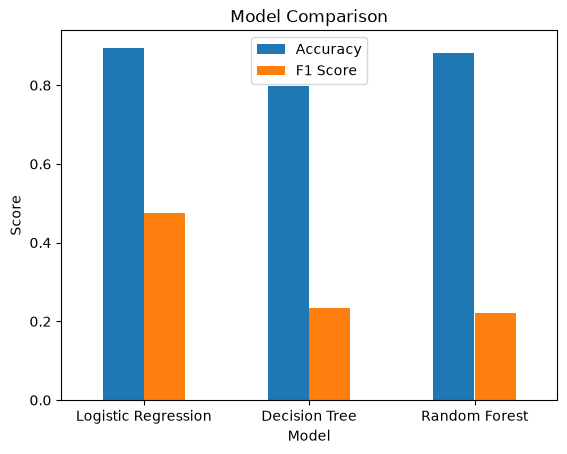

In [ ]:
results.plot(x="Model", y=["Accuracy", "F1 Score"], kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

CONCLUSION

In [ ]:
"""after creating all 3 models and  training and test them i found logistic regession is the best model from these 3 model for this dataset
logistic regression has high acceracy n F1 Score also
acc:0.894558
"""

'after creating all 3 models and  training and test them i found logistic regession is the best model from these 3 model for this dataset'